### Introduction to Decision Trees

Decision trees are a popular supervised machine learning algorithm used for classification and regression tasks. They work by splitting the data into subsets based on feature values, creating a tree-like model of decisions. Each internal node represents a decision based on an attribute, each branch represents the outcome of that decision, and each leaf node represents a final outcome.

![](https://d2jdgazzki9vjm.cloudfront.net/tutorial/machine-learning/images/decision-tree-classification-algorithm.png)

## Example
![](https://d2jdgazzki9vjm.cloudfront.net/tutorial/machine-learning/images/decision-tree-classification-algorithm2.png)

![dt.jpg](attachment:dt.jpg)

![image.png](attachment:image.png)

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

Part 1:- https://medium.com/@ankitnitjsr13/math-behind-decision-tree-algorithm-2aa398561d6d

Part 2 : https://ankitnitjsr13.medium.com/decision-tree-algorithm-id3-d512db495c90


### Entropy and Information Gain

**Entropy** is a measure of uncertainty or randomness in a dataset. In the context of decision trees, it helps quantify the impurity or disorder in a set of examples. The formula for entropy \( H \) is:

\[
H(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)
\]

where \( p_i \) is the proportion of class \( i \) in the dataset.

**Information Gain** measures the effectiveness of an attribute in reducing uncertainty. It is calculated as the difference between the entropy of the original dataset and the weighted sum of the entropies of the subsets created by splitting on that attribute:

\[
IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v)
\]

where \( S \) is the original dataset, \( A \) is the attribute, and \( S_v \) are the subsets of \( S \) created by the split.

### Gini Index

The **Gini Index** is another criterion for measuring impurity, often used in decision trees like CART (Classification and Regression Trees). It is calculated as:

\[
Gini(S) = 1 - \sum_{i=1}^{c} p_i^2
\]

A lower Gini index indicates a better split, meaning the nodes are purer (more homogenous). The Gini index can be used in a similar way to information gain to determine the best attribute for splitting.

### CART and CHAID

- **CART (Classification and Regression Trees)**: This algorithm builds binary trees using the Gini index for classification and mean squared error for regression. It uses binary splits and can handle both numerical and categorical data.

- **CHAID (Chi-squared Automatic Interaction Detector)**: CHAID is based on the chi-squared statistical test to decide the best split for a categorical dependent variable. It can produce trees with multiple branches at each node and is more suited for categorical data.




### Performance Metrics

To evaluate the performance of decision trees, several metrics can be used:

- **Accuracy**: The proportion of correctly classified instances.
  
- **Precision**: The ratio of true positive predictions to the total predicted positives.
  
- **Recall (Sensitivity)**: The ratio of true positive predictions to the actual positives.
  
- **F1 Score**: The harmonic mean of precision and recall, useful for imbalanced datasets.
  
- **ROC-AUC**: The area under the receiver operating characteristic curve, providing insight into the trade-off between true positive rate and false positive rate.

### Pruning Techniques

**Pruning** is a technique used to reduce the size of the decision tree and prevent overfitting. It involves removing nodes that provide little predictive power. Common pruning methods include:

- **Pre-pruning**: Stops the tree from growing when further splits do not significantly improve performance. Criteria can include a maximum depth or minimum samples per leaf.

- **Post-pruning**: Grows the full tree first and then removes nodes based on performance on a validation set. Techniques include cost-complexity pruning, which balances tree complexity and training error.

By understanding these concepts, you can effectively use decision trees in various machine learning tasks, ensuring robust models that generalize well to new data.

https://www.analyticsvidhya.com/blog/2021/07/a-comprehensive-guide-to-decision-trees/

## Classification code using Iris Dataset


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [70]:
# Load the iris dataset
from sklearn.datasets import load_iris

data = load_iris()
df = pd.DataFrame(data.data, columns = data.feature_names)
df['target'] = data.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [71]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [72]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [73]:
X = df.drop("target", axis=1) # feature/colums/inputs
y = df['target'] # output /label

In [74]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=1)

In [75]:
# Create a Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier()

# for impurites measures (gini(0,0.5)->for large dataset, entropy(0-1) for small dataset because of computations )
# On what feature to split the data using information gain  --> check the impurity --> feature with highest information gain select 1st
classifier

DecisionTreeClassifier()

In [76]:
# Train the model
classifier.fit(X_train, y_train)

DecisionTreeClassifier()

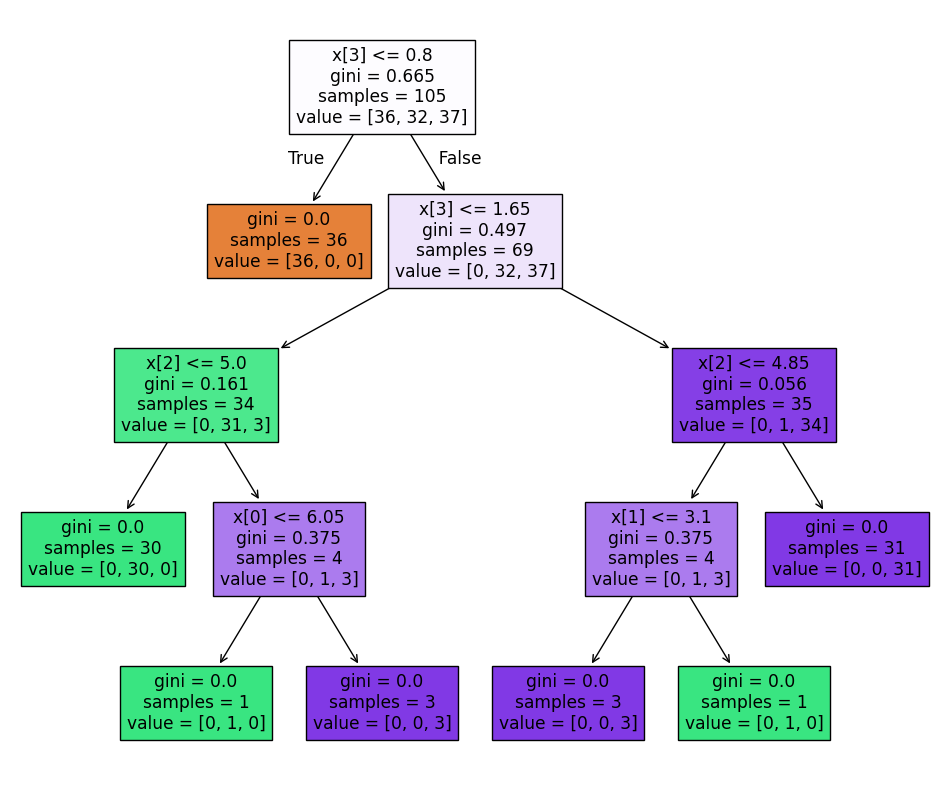

In [77]:
# show the visual tree of decision tree
from sklearn import tree
plt.figure(figsize = (12, 10))
tree.plot_tree(classifier, filled = True)
plt.show()

In [78]:
# Make predictions
classifier.predict(X_test)
y_predict = classifier.predict(X_test)

In [79]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_test, y_predict)

0.9555555555555556

## Apply Purinig -->post purning


In [80]:
#post pruning
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='entropy', max_depth = 3)
classifier
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

[Text(0.375, 0.875, 'x[3] <= 0.8\nentropy = 1.582\nsamples = 105\nvalue = [36, 32, 37]'),
 Text(0.25, 0.625, 'entropy = 0.0\nsamples = 36\nvalue = [36, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[3] <= 1.65\nentropy = 0.996\nsamples = 69\nvalue = [0, 32, 37]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[2] <= 5.0\nentropy = 0.431\nsamples = 34\nvalue = [0, 31, 3]'),
 Text(0.125, 0.125, 'entropy = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(0.375, 0.125, 'entropy = 0.811\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.75, 0.375, 'x[2] <= 4.85\nentropy = 0.187\nsamples = 35\nvalue = [0, 1, 34]'),
 Text(0.625, 0.125, 'entropy = 0.811\nsamples = 4\nvalue = [0, 1, 3]'),
 Text(0.875, 0.125, 'entropy = 0.0\nsamples = 31\nvalue = [0, 0, 31]')]

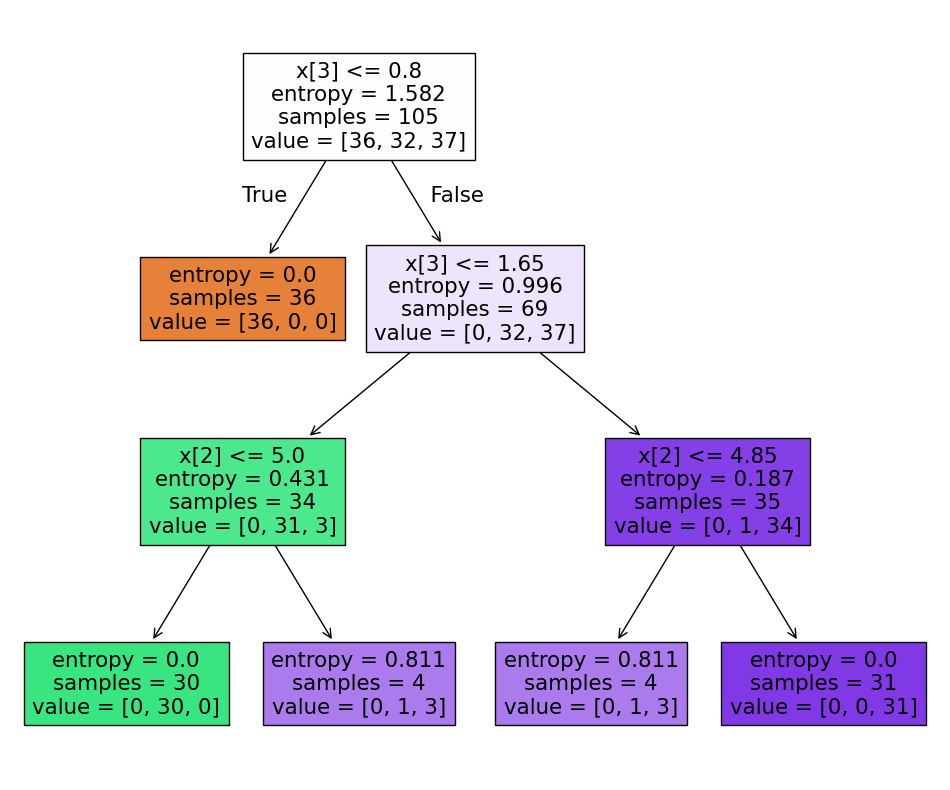

In [81]:
from sklearn import tree
plt.figure(figsize = (12, 10))
tree.plot_tree(classifier, filled = True)

In [82]:
print(f' training accuracy: {classifier.score(X_train, y_train)}')

print(f' test accuracy: {classifier.score(X_test, y_test)}')

 training accuracy: 0.9809523809523809
 test accuracy: 0.9555555555555556


In [83]:
y_pred = classifier.predict(X_test)
y_pred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 1, 2, 2, 0, 1, 0, 1, 2, 2, 0, 1, 2,
       1])

In [84]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_test, y_pred)

0.9555555555555556

# Evaluate the model

In [85]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        18
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [86]:
# Evaluate the model
from sklearn.metrics import confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Print the results
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.96
Confusion Matrix:
 [[14  0  0]
 [ 0 17  1]
 [ 0  1 12]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.94      0.94      0.94        18
           2       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



## hyperparameter tuning

Hyperparameter tuning is the process of selecting the optimal configuration of hyperparameters—parameters set before training, like learning rate or tree depth—to maximize machine learning model performance.

Types 

1. GridSearchCV   (Fit all parameter combinations and then show best parameters)
2. RandomSearchCV (Fit only N parameter combinations and then show best parameters) N=number of iterations

3. Bayesian optimization 
    it  is an efficient, iterative strategy for hyperparameter tuning that models model performance as a probability distribution, allowing it to find optimal parameters faster than grid or random search.

- CV/Crossvalidations --> Cross-validation is a robust, iterative resampling technique used to evaluate machine learning model performance and prevent overfitting by training and testing on multiple subsets of the data.

Types of CV
- LOOCV (leave one out CV)
- K-fold cross-validation

In [87]:
decision_tree = DecisionTreeClassifier(criterion='gini', max_depth=1, min_samples_leaf=3)
decision_tree.fit(X_train, y_train)
print(f' training accuracy: {decision_tree.score(X_train, y_train)}')
print(f' test accuracy: {decision_tree.score(X_test, y_test)}')

 training accuracy: 0.6952380952380952
 test accuracy: 0.6


In [88]:
height =[1,2,7,4,5]
criterion =['gini', 'entropy']
# min_samples_leaf =[1,2,3,4,5]

for i in height:
    print('max_depth ', i)
    decision_tree = DecisionTreeClassifier(criterion='gini', max_depth=i, min_samples_leaf=3)
    decision_tree.fit(X_train, y_train)
    print(f' training accuracy: {decision_tree.score(X_train, y_train)}')
    print(f' test accuracy: {decision_tree.score(X_test, y_test)}')

max_depth  1
 training accuracy: 0.6952380952380952
 test accuracy: 0.6
max_depth  2
 training accuracy: 0.9619047619047619
 test accuracy: 0.9555555555555556
max_depth  7
 training accuracy: 0.9809523809523809
 test accuracy: 0.9555555555555556
max_depth  4
 training accuracy: 0.9809523809523809
 test accuracy: 0.9555555555555556
max_depth  5
 training accuracy: 0.9809523809523809
 test accuracy: 0.9555555555555556


In [89]:
#prepruning>> hyperparameter tuning
parameter = {
    'criterion': ['gini', 'entropy'],
    'max_depth':[ 1,2,4, 8],
    'splitter':['best', 'random']
}

In [90]:
from sklearn.model_selection import GridSearchCV # check all parameter  combinations

In [98]:
clf = DecisionTreeClassifier()
clf

DecisionTreeClassifier()

In [99]:
model = GridSearchCV(clf, param_grid=parameter, cv = 5, scoring = "accuracy",verbose=3)
model

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 4, 8],
                         'splitter': ['best', 'random']},
             scoring='accuracy', verbose=3)

In [100]:
model.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END criterion=gini, max_depth=1, splitter=best;, score=0.714 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, splitter=best;, score=0.714 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, splitter=best;, score=0.714 total time=   0.1s
[CV 4/5] END criterion=gini, max_depth=1, splitter=best;, score=0.667 total time=   0.1s
[CV 5/5] END criterion=gini, max_depth=1, splitter=best;, score=0.667 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=1, splitter=random;, score=0.714 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, splitter=random;, score=0.714 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, splitter=random;, score=0.476 total time=   0.1s
[CV 4/5] END criterion=gini, max_depth=1, splitter=random;, score=0.667 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=1, splitter=random;, score=0.667 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 2, 4, 8],
                         'splitter': ['best', 'random']},
             scoring='accuracy', verbose=3)

In [102]:
model.best_params_

{'criterion': 'entropy', 'max_depth': 4, 'splitter': 'random'}

In [103]:
model = model.best_estimator_

In [104]:
model.score(X_train, y_train)

0.9714285714285714

In [105]:
model.score(X_test, y_test)

0.9777777777777777

In [106]:
#prepruning>> hyperparameter tuning
parameter = {
    'criterion': ['gini', 'entropy'],
    'max_depth':[ 1,2,4, 8],
    'splitter':['best', 'random']
}
# random searchcv 
from sklearn.model_selection import RandomizedSearchCV
model2 = RandomizedSearchCV(clf, param_distributions=parameter, cv = 5, scoring = "accuracy",verbose=3,n_iter=8)
model2

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_iter=8,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [1, 2, 4, 8],
                                        'splitter': ['best', 'random']},
                   scoring='accuracy', verbose=3)

In [107]:
model2.fit(X_train,y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END criterion=gini, max_depth=8, splitter=best;, score=1.000 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=8, splitter=best;, score=0.952 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=8, splitter=best;, score=1.000 total time=   0.2s


[CV 4/5] END criterion=gini, max_depth=8, splitter=best;, score=0.952 total time=   0.1s
[CV 5/5] END criterion=gini, max_depth=8, splitter=best;, score=0.857 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=8, splitter=random;, score=0.952 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=8, splitter=random;, score=0.857 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=8, splitter=random;, score=0.952 total time=   0.1s
[CV 4/5] END criterion=gini, max_depth=8, splitter=random;, score=0.857 total time=   0.3s
[CV 5/5] END criterion=gini, max_depth=8, splitter=random;, score=0.857 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=4, splitter=random;, score=1.000 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=4, splitter=random;, score=0.905 total time=   0.4s
[CV 3/5] END criterion=gini, max_depth=4, splitter=random;, score=0.857 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=4, splitter=random;, score=0.952 total time=   1.1s
[CV

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_iter=8,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [1, 2, 4, 8],
                                        'splitter': ['best', 'random']},
                   scoring='accuracy', verbose=3)

In [108]:
model2.score(X_test, y_test)

0.9555555555555556

##  Decision tree Regression Code (california_housing_predictions)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')


from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns = data.feature_names)

In [ ]:
df['Price'] = data.target

In [ ]:
df

In [ ]:
df = df.sample(frac = 0.20)

In [ ]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
X
y

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=1)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

In [ ]:
parameter = {
    'criterion': ['squared_error', 'poissor'],
    'max_depth':[1, 2, 3, 4, 6, 8],
    'splitter':['best', 'random'],
    'max_features': ['sqrt', 'log2']
}
reg = DecisionTreeRegressor()

In [ ]:
from sklearn.model_selection import GridSearchCV
model = GridSearchCV(reg, param_grid = parameter, cv = 5, scoring = "neg_mean_squared_error")

In [ ]:
model.fit(X_train, y_train)

In [ ]:
model.best_params_

In [ ]:
final_model = DecisionTreeRegressor(criterion = "squared_error", max_depth = 6)

In [ ]:
final_model.fit(X_train, y_train)

In [ ]:
from sklearn import tree
plt.figure(figsize = (12, 10))

tree.plot_tree(final_model, filled = True)
plt.show()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2_score(y_test, y_pred)

In [ ]:
# # print the scores on training and test set
# ### Check for overfitting and underfitting
# print('Training set score: {:.4f}'.format(model.score(X_train, y_train)))

# print('Test set score: {:.4f}'.format(model.score(X_test, y_test)))

https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

multiclass classifications

<a class="anchor" id="0"></a>
# **Decision Tree Classifier Tutorial with Python using car dataset**


Hello friends,

In this kernel, I build a Decision Tree Classifier to predict the safety of the car. I build two models, one with criterion `gini index` and another one with criterion `entropy`. I implement Decision Tree Classification with Python and Scikit-Learn.

<a class="anchor" id="0.1"></a>
# **Table of Contents**


1.	[Introduction to Decision Tree algorithm](#1)
2.	[Classification and Regression Trees](#2)
3.	[Decision Tree algorithm terminology](#3)
4.	[Decision Tree algorithm intuition](#4)
5.	[Attribute selection measures](#5)
    - 5.1 [Information gain](#5.1)
    - 5.2 [Gini index](#5.2)
6.	[Overfitting in Decision-Tree algorithm](#6)
7.	[Import libraries](#7)
8.	[Import dataset](#8)
9.	[Exploratory data analysis](#9)
10.	[Declare feature vector and target variable](#10)
11.	[Split data into separate training and test set](#11)
12.	[Feature engineering](#12)
13.	[Decision Tree classifier with criterion gini-index](#13)
14.	[Decision Tree classifier with criterion entropy](#14)
15.	[Confusion matrix](#15)
16.	[Classification report](#16)
17.	[Results and conclusion](#17)
18. [References](#18)


# **1. Introduction to Decision Tree algorithm** <a class="anchor" id="1"></a>

[Table of Contents](#0.1)

A Decision Tree algorithm is one of the most popular machine learning algorithms. It uses a tree like structure and their possible combinations to solve a particular problem. It belongs to the class of supervised learning algorithms where it can be used for both classification and regression purposes.


A decision tree is a structure that includes a root node, branches, and leaf nodes. Each internal node denotes a test on an attribute, each branch denotes the outcome of a test, and each leaf node holds a class label. The topmost node in the tree is the root node.


We make some assumptions while implementing the Decision-Tree algorithm. These are listed below:-

1. At the beginning, the whole training set is considered as the root.
2. Feature values need to be categorical. If the values are continuous then they are discretized prior to building the model.
3. Records are distributed recursively on the basis of attribute values.
4. Order to placing attributes as root or internal node of the tree is done by using some statistical approach.


I will describe Decision Tree terminology in later section.


# **2. Classification and Regression Trees (CART)** <a class="anchor" id="2"></a>

[Table of Contents](#0.1)


Nowadays, Decision Tree algorithm is known by its modern name **CART** which stands for **Classification and Regression Trees**. Classification and Regression Trees or **CART** is a term introduced by Leo Breiman to refer to Decision Tree algorithms that can be used for classification and regression modeling problems.


The CART algorithm provides a foundation for other important algorithms like bagged decision trees, random forest and boosted decision trees. In this kernel, I will solve a classification problem. So, I will refer the algorithm also as Decision Tree Classification problem.


# **3. Decision Tree algorithm terminology** <a class="anchor" id="3"></a>

[Table of Contents](#0.1)


- In a Decision Tree algorithm, there is a tree like structure in which each internal node represents a test on an attribute, each branch represents the outcome of the test, and each leaf node represents a class label. The paths from the root node to leaf node represent classification rules.

- We can see that there is some terminology involved in Decision Tree algorithm. The terms involved in Decision Tree algorithm are as follows:-


## **Root Node**

- It represents the entire population or sample. This further gets divided into two or more homogeneous sets.


## **Splitting**

- It is a process of dividing a node into two or more sub-nodes.


## Decision Node

- When a sub-node splits into further sub-nodes, then it is called a decision node.


## Leaf/Terminal Node

- Nodes that do not split are called Leaf or Terminal nodes.


## Pruning

- When we remove sub-nodes of a decision node, this process is called pruning. It is the opposite process of splitting.


## Branch/Sub-Tree

- A sub-section of an entire tree is called a branch or sub-tree.


## Parent and Child Node

- A node, which is divided into sub-nodes is called the parent node of sub-nodes where sub-nodes are the children of a parent node.


The above terminology is represented clearly in the following diagram:-

### Decision-Tree terminology

![Decision-Tree terminology](https://gdcoder.com/content/images/2019/05/Screen-Shot-2019-05-18-at-03.40.41.png)

# **4. Decision Tree algorithm intuition** <a class="anchor" id="4"></a>

[Table of Contents](#0.1)

The Decision-Tree algorithm is one of the most frequently and widely used supervised machine learning algorithms that can be used for both classification and regression tasks. The intuition behind the Decision-Tree algorithm is very simple to understand.


The Decision Tree algorithm intuition is as follows:-


1.	For each attribute in the dataset, the Decision-Tree algorithm forms a node. The most important attribute is placed at the root node.

2.	For evaluating the task in hand, we start at the root node and we work our way down the tree by following the corresponding node that meets our condition or decision.

3.	This process continues until a leaf node is reached. It contains the prediction or the outcome of the Decision Tree.


# **5. Attribute selection measures** <a class="anchor" id="5"></a>

[Table of Contents](#0.1)


The primary challenge in the Decision Tree implementation is to identify the attributes which we consider as the root node and each level. This process is known as the **attributes selection**. There are different attributes selection measure to identify the attribute which can be considered as the root node at each level.


There are 2 popular attribute selection measures. They are as follows:-


- **Information gain**

- **Gini index**


While using **Information gain** as a criterion, we assume attributes to be categorical and for **Gini index** attributes are assumed to be continuous. These attribute selection measures are described below.


![](https://cdn.analyticsvidhya.com/wp-content/uploads/2024/09/ns1.webp)

## **5.1 Information gain** <a class="anchor" id="5.1"></a>

[Table of Contents](#0.1)


By using information gain as a criterion, we try to estimate the information contained by each attribute. To understand the concept of Information Gain, we need to know another concept called **Entropy**.

## **Entropy**

Entropy measures the impurity in the given dataset. In Physics and Mathematics, entropy is referred to as the randomness or uncertainty of a random variable X. In information theory, it refers to the impurity in a group of examples. **Information gain** is the decrease in entropy. Information gain computes the difference between entropy before split and average entropy after split of the dataset based on given attribute values.

Entropy is represented by the following formula:-




![Entropy](http://www.learnbymarketing.com/wp-content/uploads/2016/02/entropy-formula.png)



Here, **c** is the number of classes and **pi** is the probability associated with the ith class.

The ID3 (Iterative Dichotomiser) Decision Tree algorithm uses entropy to calculate information gain. So, by calculating decrease in **entropy measure** of each attribute we can calculate their information gain. The attribute with the highest information gain is chosen as the splitting attribute at the node.

## **5.2 Gini index** <a class="anchor" id="5.2"></a>

[Table of Contents](#0.1)


Another attribute selection measure that **CART (Categorical and Regression Trees)** uses is the **Gini index**. It uses the Gini method to create split points.


Gini index can be represented with the following diagram:-

## **Gini index**

![Gini index](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRzYHkcmZKKp2sJN1HpHvw-NgqbD9EnapnbXozXRgajrSGvEnYy&s)


Here, again **c** is the number of classes and **pi** is the probability associated with the ith class.

Gini index says, if we randomly select two items from a population, they must be of the same class and probability for this is 1 if the population is pure.

It works with the categorical target variable “Success” or “Failure”. It performs only binary splits. The higher the value of Gini, higher the homogeneity. CART (Classification and Regression Tree) uses the Gini method to create binary splits.

Steps to Calculate Gini for a split

1.	Calculate Gini for sub-nodes, using formula sum of the square of probability for success and failure (p^2+q^2).

2.	Calculate Gini for split using weighted Gini score of each node of that split.


In case of a discrete-valued attribute, the subset that gives the minimum gini index for that chosen is selected as a splitting attribute. In the case of continuous-valued attributes, the strategy is to select each pair of adjacent values as a possible split-point and point with smaller gini index chosen as the splitting point. The attribute with minimum Gini index is chosen as the splitting attribute.

# **6. Overfitting in Decision Tree algorithm** <a class="anchor" id="6"></a>

[Table of Contents](#0.1)


Overfitting is a practical problem while building a Decision-Tree model. The problem of overfitting is considered when the algorithm continues to go deeper and deeper to reduce the training-set error but results with an increased test-set error. So, accuracy of prediction for our model goes down. It generally happens when we build many branches due to outliers and irregularities in data.

Two approaches which can be used to avoid overfitting are as follows:-

- Pre-Pruning

- Post-Pruning


## **Pre-Pruning**

In pre-pruning, we stop the tree construction a bit early. We prefer not to split a node if its goodness measure is below a threshold value. But it is difficult to choose an appropriate stopping point.


## **Post-Pruning**

In post-pruning, we go deeper and deeper in the tree to build a complete tree. If the tree shows the overfitting problem then pruning is done as a post-pruning step. We use the cross-validation data to check the effect of our pruning. Using cross-validation data, we test whether expanding a node will result in improve or not. If it shows an improvement, then we can continue by expanding that node. But if it shows a reduction in accuracy then it should not be expanded. So, the node should be converted to a leaf node.